In [1]:
from google.colab import files
uploaded = files.upload()

# After uploading, load it into pandas
import pandas as pd
import io
df = pd.read_csv(io.BytesIO(uploaded['iris.csv']))

Saving iris.csv to iris.csv


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('iris.csv')

In [4]:
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
54,55,6.5,2.8,4.6,1.5,Iris-versicolor
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
145,146,6.7,3.0,5.2,2.3,Iris-virginica
90,91,5.5,2.6,4.4,1.2,Iris-versicolor
2,3,4.7,3.2,1.3,0.2,Iris-setosa


<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

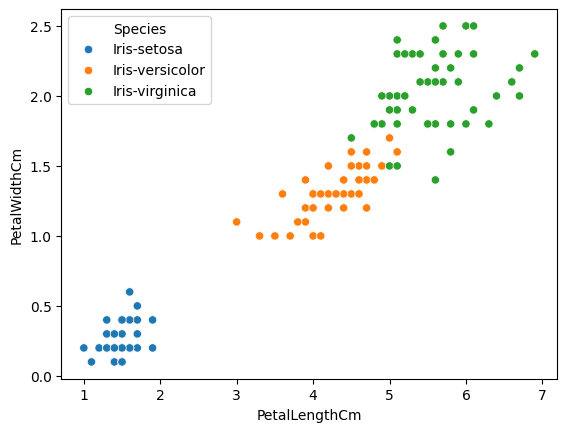

In [12]:
import seaborn as sns
sns.scatterplot(
    x=df['PetalLengthCm'],
    y=df['PetalWidthCm'],
    hue=df['Species']
)

In [15]:
x = df.drop(columns = ["Id","Species"])
y = df["Species"]

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [32]:
from sklearn.tree import DecisionTreeClassifier
for i in range(2,5):
  dt = DecisionTreeClassifier(criterion= "gini",splitter = "random",max_depth = i,random_state = 42)
  dt.fit(x_train,y_train)
  y_pred = dt.predict(x_test)

  from sklearn.metrics import accuracy_score
  print("Depth:", i, "Accuracy:", accuracy_score(y_test, y_pred))


Depth: 2 Accuracy: 0.9333333333333333
Depth: 3 Accuracy: 0.9333333333333333
Depth: 4 Accuracy: 0.9333333333333333
Depth: 5 Accuracy: 0.9333333333333333
Depth: 6 Accuracy: 0.9333333333333333


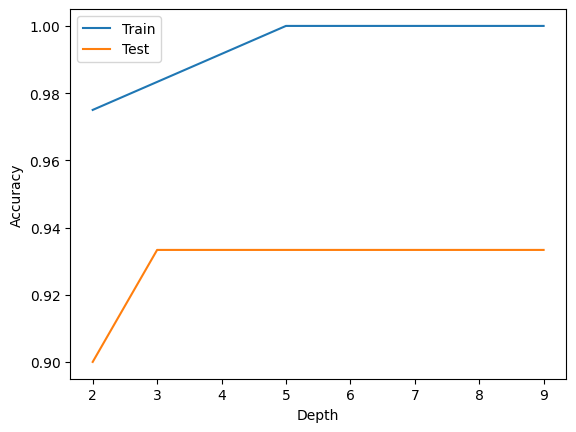

In [34]:
import matplotlib.pyplot as plt

depths = []
train_scores = []
test_scores = []

for i in range(2, 10):
    dt = DecisionTreeClassifier(max_depth=i, random_state=42)
    dt.fit(x_train, y_train)

    depths.append(i)
    train_scores.append(accuracy_score(y_train, dt.predict(x_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(x_test)))

plt.plot(depths, train_scores, label="Train")
plt.plot(depths, test_scores, label="Test")
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5)
grid.fit(x_train, y_train)

print(grid.best_params_)

{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
